 # معضلة الحفظ والفهم: تقدير الوصف



 إن معيار الخطأ يكون بحسب نوع القيمة المقدَّرة: عددية أو وصفية.

 نولد فيما يلي بيانات تصنيف وهمية مع شيء من العشوائية لاستعمالها للتوضيح:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(11)
m = 200
X, y = make_moons(n_samples=m, noise=0.3, random_state=42)


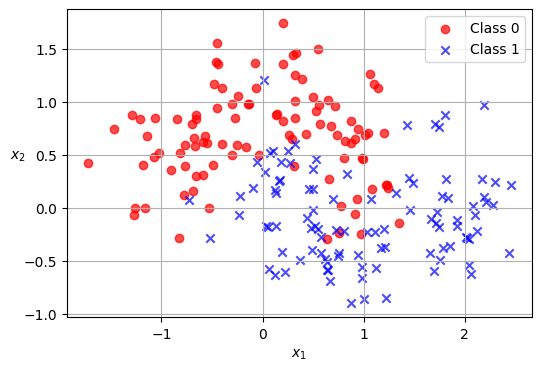

In [2]:
plt.figure(figsize=(6, 4))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', alpha=0.7, label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', alpha=0.7, label="Class 1")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.legend()
plt.grid()
plt.show()


 - نلائم 6 نماذج دقيقة تزيد في تعقيدها (عمق شجرة القرار) لزيادة التفاصيل التي تستطيع تمثيلها

 - ثم نقيس الدقة في التصنيف (Accuracy)

 - سؤال: ما هو النموذج الأكثر ملاءمة للبيانات في نظرك؟

/tmp/ipykernel_297204/413837567.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', s=30, edgecolor='k', alpha=0.7)
/tmp/ipykernel_297204/413837567.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', s=30, edgecolor='k', alpha=0.7)
/tmp/ipykernel_297204/413837567.py:39: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', s=30, edgecolor='k', alpha=0.7)
/tmp/ipykernel_2972

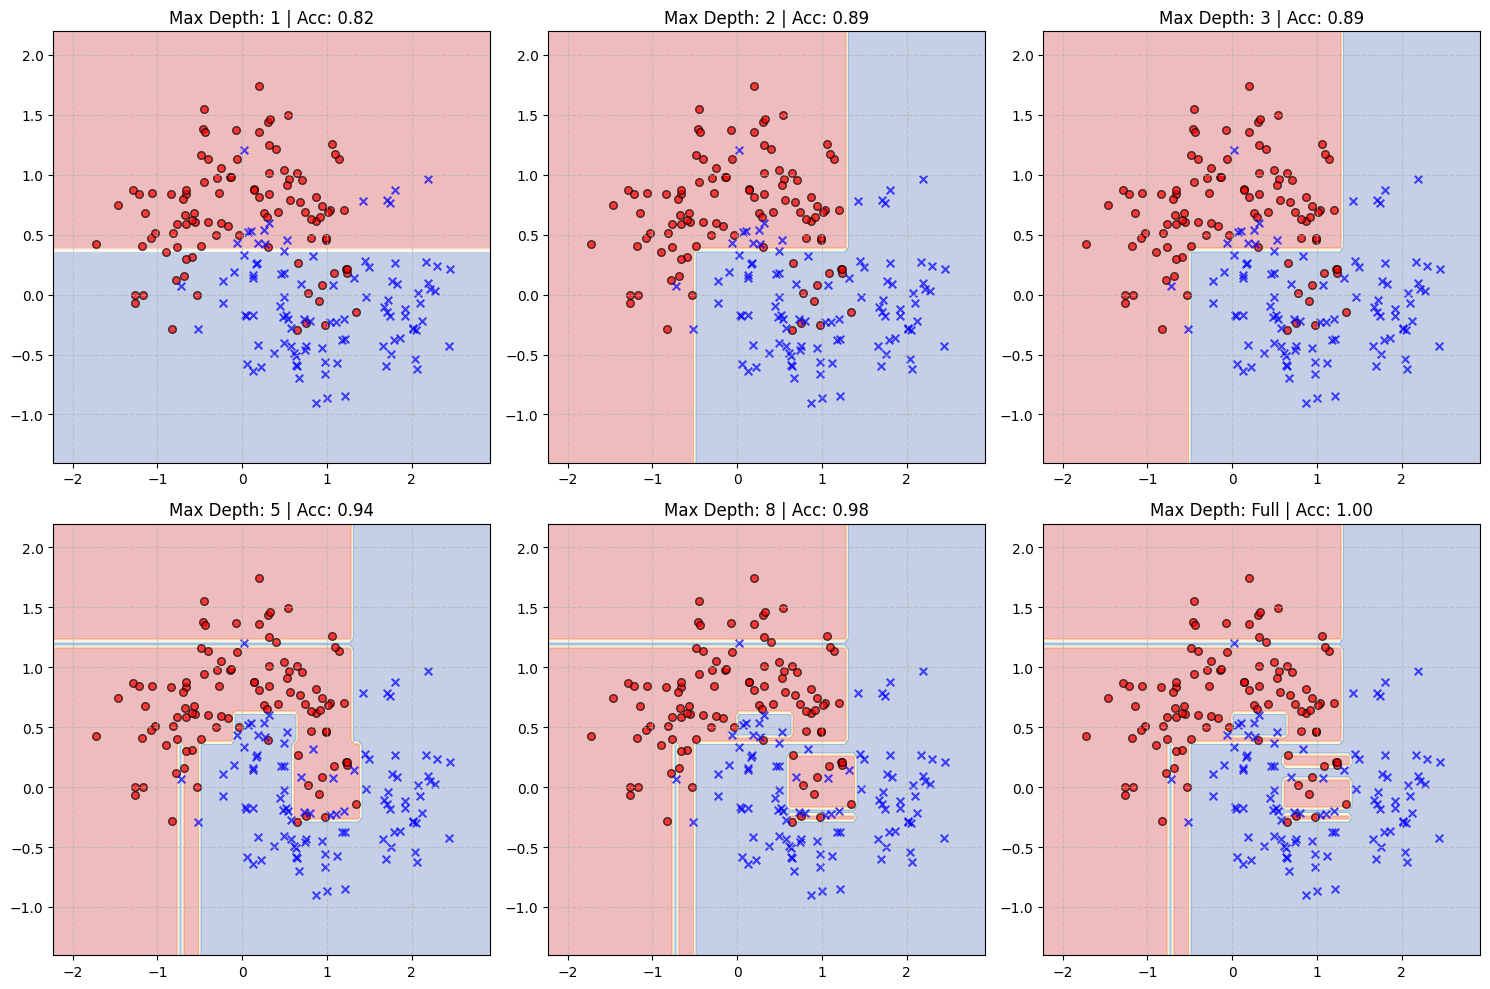

In [3]:
# | code-fold: true

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 2. Setup for Predictions
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

depths = [1, 2, 3, 5, 8, None] 
scores = {} # Dictionary to store scores

# 4. Plotting using Subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, depth in enumerate(depths):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X, y)
    
    # Calculate Score
    scores[depth] = accuracy_score(y, model.predict(X))
    
    ax = axes[i]
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Plot training data
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', s=30, edgecolor='k', alpha=0.7)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', s=30, edgecolor='k', alpha=0.7)
    
    # Updated title to include the score
    title_depth = depth if depth is not None else "Full"
    ax.set_title(f"Max Depth: {title_depth} | Acc: {scores[depth]:.2f}")
    
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


 ## اختيار النموذج الأمثل



 **التعميم** (Generalization): هو مدى ملاءمة النموذج لبيانات لم يعاينها أثناء التدريب. ويُقاسُ بمعيار الخطأ.



 والنموذج الواحد يدخل عليه الخطأ من ناحيتين متعارضتين: **الانحياز** (Bias) و**التباين** (Variance).



 فأما **التباين** (Variance):  ويعني تفاوُتَ الخطأ بمخالفة عينات التدريب. وسبب ذلك كثرة تفصيل النموذج (بكثرة المعاملات) أو قلة البيانات (ضعف البيانات عن التعبير عن النمط العام) أو كلاهما. ويسمى فرط الملاءمة (Over-fitting).



 وأما **الانحياز** (Bias): وهو بقدر مجموع الخطأ وإن لم يكن يتفاوت مع تغيير عينة التدريب. وسبب ذلك بساطة النموذج عن تمثيل التفاصيل في البيانات؛ إما لقلة المعاملات أو ضعف تركيبها. ويسمى نقص الملاءمة (Under-fitting).



 والنموذج الأمثل (Good-fit) وسطٌ بينهما:



 - فالنموذَجُ: فيه من القدرة على التفصيل ما يناسب النمط الصغير، وفيه من القدرة على الإجمال ما يناسب النمط الكبير.

 - والبيانات: مُبِينَة للنمطين: الكبير والصغير.

 لنبين هذا الأمر، نعاين بيانات التدريب (مع الإرجاع) تسع مرات وننقطها في الشكل التالي:

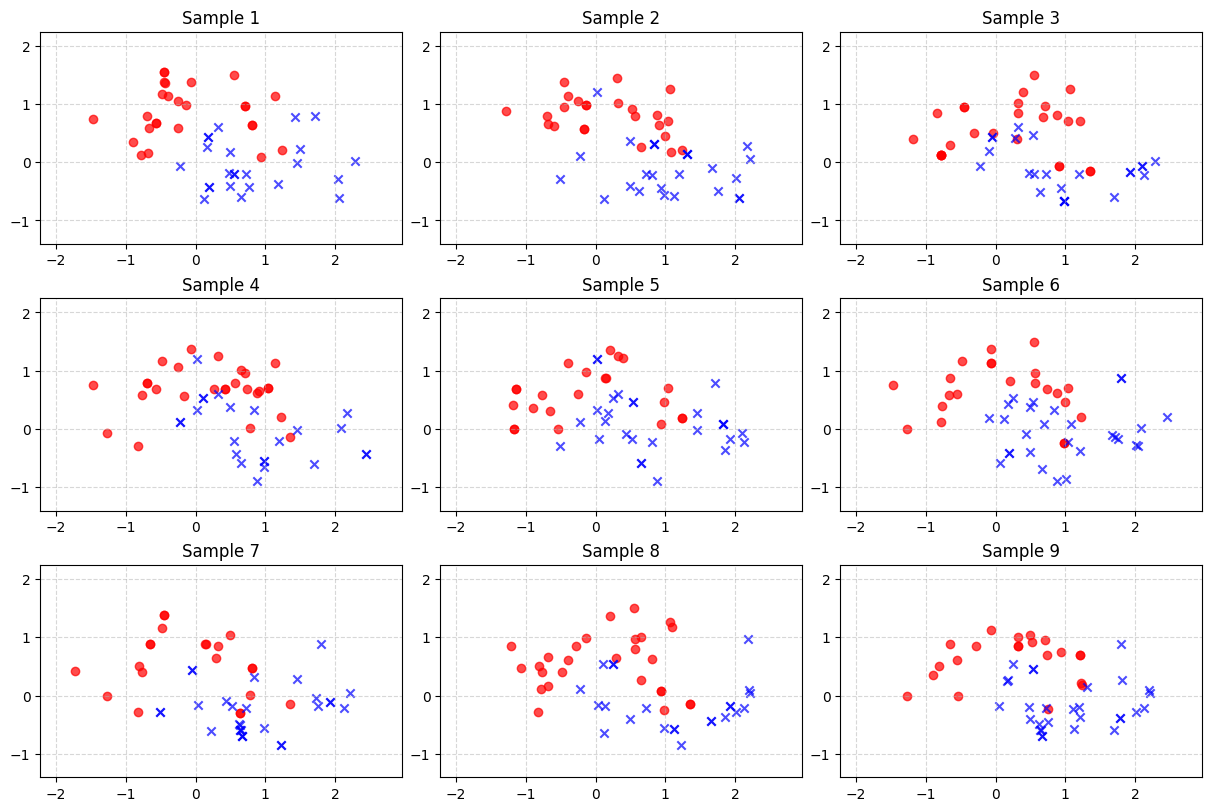

In [4]:
# | code-fold: true

import numpy as np
import matplotlib.pyplot as plt

# 2. Create a 3x3 grid of subplots
# Using constrained_layout to prevent overlap
fig, axes = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()  # Flatten to iterate easily

for i in range(9):
    # Perform sampling with replacement
    indices = np.random.choice(np.arange(len(y)), size=50, replace=True)
    x_sample = X[indices]
    y_sample = y[indices]

    # 3. Plot the sampled points
    axes[i].scatter(x_sample[y_sample == 0, 0], x_sample[y_sample == 0, 1], color='red', marker='o', alpha=0.7)
    axes[i].scatter(x_sample[y_sample == 1, 0], x_sample[y_sample == 1, 1], color='blue', marker='x', alpha=0.7)
    
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    
    axes[i].set_title(f'Sample {i+1}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.show()


 لاحظ حين نلائم ثلاث نماذج على عينات من بيانات التدريب كيف يؤثر ذلك على تغير حدود اتخاذ القرار (Decision Boundaries):



 - في أي هذه النماذج تجد التفاوُت أكبر؟

 - وفي أيها تجد التفاوُتَ أقل ما يكون؟

 - برأيك أي النماذج هو الأمثل بينها؟

In [45]:
# 1. Define the models in a dictionary for easy iteration
models = {
    "m1": DecisionTreeClassifier(max_depth=1, random_state=42),
    "m2": DecisionTreeClassifier(max_depth=2, random_state=42),
    "m3": DecisionTreeClassifier(max_depth=8, random_state=42)
}

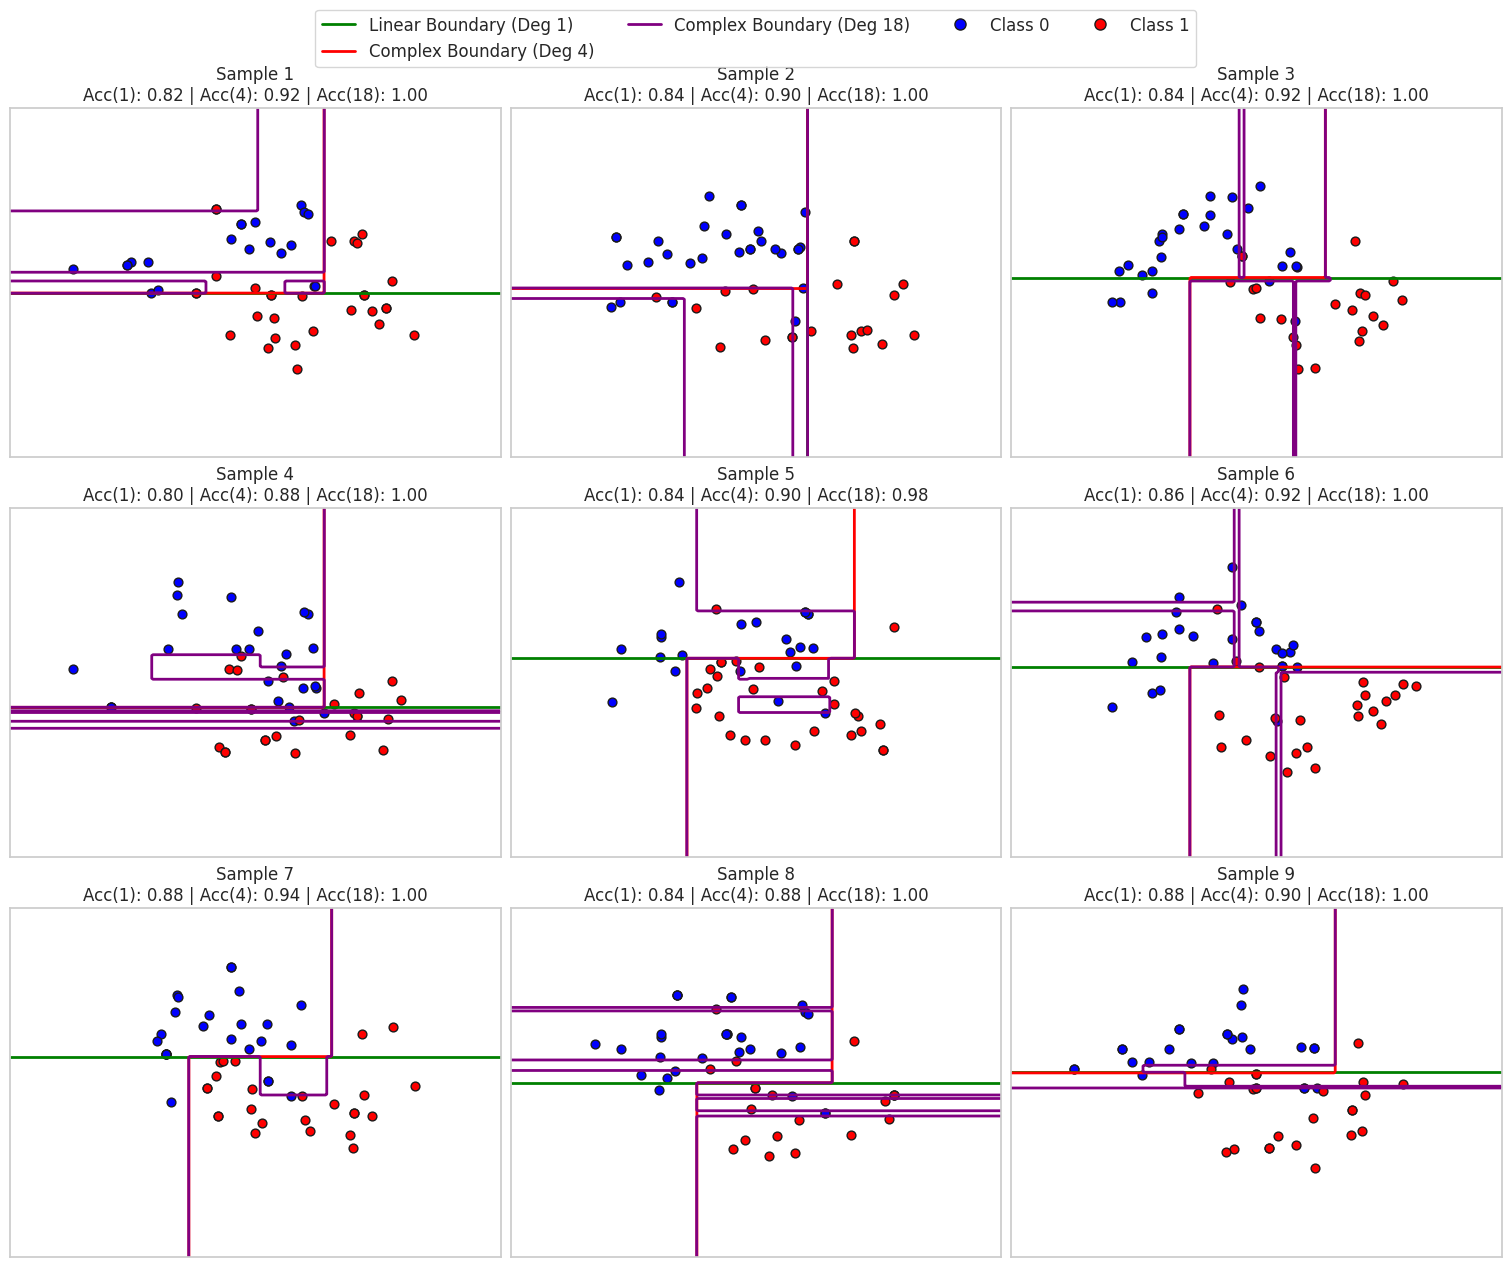

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


# 2. Setup plotting grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

x_min, x_max = -2.5, 3.5
y_min, y_max = -2.0, 2.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

for i in range(9):
    # Perform sampling with replacement
    indices = np.random.choice(np.arange(len(y)), size=50, replace=True)
    X_sample = X[indices]
    y_sample = y[indices]

     # --- Pipeline 1 ---
    pipeline1 = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', models["m1"]),
    ])
    clf1 = pipeline1.fit(X_sample, y_sample)
    
    # --- Pipeline 2 ---
    pipeline2 = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', models["m2"])
    ])
    clf2 = pipeline2.fit(X_sample, y_sample)

     # --- Pipeline 3 ---
    pipeline3 = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', models["m3"])
    ])
    clf5 = pipeline3.fit(X_sample, y_sample)

    # Plot Decision Boundaries (Threshold at 0.5)
    for clf, color, label in zip([clf1, clf2, clf5], ['green', 'red', 'purple'], ['Deg 1', 'Deg 4', 'Deg 18']):
        # Using predict_proba for the boundary line as well
        Z = clf.predict_proba(grid_points)[:, 1].reshape(xx.shape)
        axes[i].contour(xx, yy, Z, levels=[0.5], colors=color, linewidths=2)

    # Points for Class A (where y_sample is 0)
    axes[i].scatter(X_sample[y_sample == 0, 0], X_sample[y_sample == 0, 1], 
                    c='blue', edgecolors='k', s=40, label='Class 0')

    # Points for Class B (where y_sample is 1)
    axes[i].scatter(X_sample[y_sample == 1, 0], X_sample[y_sample == 1, 1], 
                    c='red', edgecolors='k', s=40, label='Class 1')
    
    acc1 = accuracy_score(y_sample, clf1.predict(X_sample))
    acc4 = accuracy_score(y_sample, clf2.predict(X_sample))
    acc18 = accuracy_score(y_sample, clf5.predict(X_sample))
    axes[i].set_title(f'Sample {i+1}\nAcc(1): {acc1:.2f} | Acc(4): {acc4:.2f} | Acc(18): {acc18:.2f}')
    axes[i].set_xticks([]); axes[i].set_yticks([])

# 3. Create a Single Unified Legend
# We create proxy artists for the contour lines since they don't behave like standard lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='Linear Boundary (Deg 1)'),
    Line2D([0], [0], color='red', lw=2, label='Complex Boundary (Deg 4)'),
    Line2D([0], [0], color='purple', lw=2, label='Complex Boundary (Deg 18)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='k', markersize=8, label='Class 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=8, label='Class 1')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize=12)

plt.show()

## التحقق المتقاطع

يتم تقسيم البيانات إلى عينة تدريب وعينة اختبار، لقياس أداء النموذج على البيانات التي لم يرها بعد. وهذا التقسيم عشوائي:

```{mermaid}
flowchart TD
    A[Dataset] -- "random 80%" --> B[Training Set]
    A -- "random 20%" --> C[Testing Set]
```

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0,
)
```

ثم يتم التدريب على القسم الأول:

```python
model.fit(X_train, ytrain)
```

والاختبار على القسم الثاني:

```python
score = model.score(X_test, y_test)
```

قد ينتج عن قياس أداء النموذج على عيِّنة الاختبار ملاءمة مثاليَّة؛ لمجرد أننا كنا محظوظين في اختيار عينتي التدريب والاختبار بحيث كانت عيِّنة التدريب مماثلة لعينة الاختبار.

أو قد نرى تبايُنًا كبيرًا أو تحيُّزًا مجحِفًا لسوء الحظ أيضًا.

ويتم تقليل نسبة الحظ بآلية **التحقق المتقاطع (cross-validation)**؛ حيث يتم تكرار عملية التقسيم العشوائي وقياس الأداء مرات ومرات، ثم يتم أخذ متوسط ذلك.

تظهر الآلية في القصاصة التالية حيث: **التقسيم مع الخلط العشوائي** (shuffle-split) مع التكرار 40 مرة.

```python
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=40, test_size=0.3, random_state=0)
cv_results = cross_validate(
    classifier,
    data,
    target,
    cv=cv, # Cross-validation Strategy
    scoring="accuracy"
)
```

 ![Figure: Shuffle Split](./assets/shufflesplit_diagram.png)

In [47]:
import pandas as pd
from sklearn.model_selection import cross_validate, ShuffleSplit
from sklearn.tree import DecisionTreeClassifier

# 2. Define the Cross-Validation Strategy
cv = ShuffleSplit(n_splits=40, test_size=0.3, random_state=0)

# 3. Execute CV for each model and collect results
performance_data = []

for name, model in models.items():
    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring="accuracy",
        return_train_score=True
    )
    
    # We store two entries per model: one for Train and one for Test.
    # This "Long-Form" structure is what plotting engines require for grouped bars.
    for train_score, test_score in zip(cv_results["train_score"], cv_results["test_score"]):
        performance_data.append({
            "Model": name,
            "Score": train_score,
            "Type": "Train"
        })
        performance_data.append({
            "Model": name,
            "Score": test_score,
            "Type": "Test"
        })


In [48]:
df_results = pd.DataFrame(performance_data)
df_results


,Model,Score,Type
0,m1,0.821429,Train
1,m1,0.816667,Test
2,m1,0.857143,Train
3,m1,0.733333,Test
4,m1,0.814286,Train
...,...,...,...
235,m3,0.916667,Test
236,m3,0.985714,Train
237,m3,0.883333,Test
238,m3,1.000000,Train


In [62]:
df_results.groupby(by=['Model', 'Type']).agg(['mean'])

Score
                 mean
Model Type           
m1    Test   0.797917
      Train  0.820714
m2    Test   0.864583
      Train  0.889107
m3    Test   0.870000
      Train  0.991786

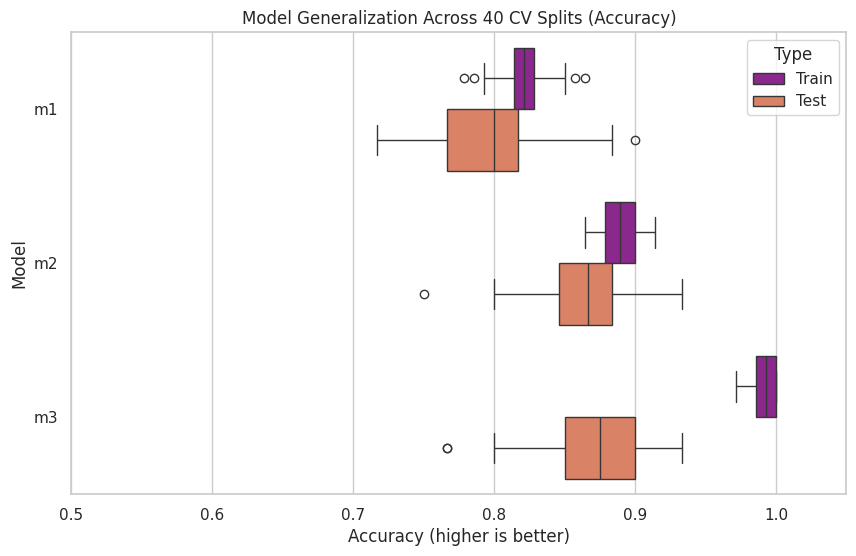

In [49]:
import seaborn as sns

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# ci="sd" draws the standard deviation. Default is a 95% confidence interval.
ax = sns.boxplot(
    data=df_results, 
    y="Model", 
    x="Score",
    orient='h', 
    hue="Type", 
    palette="plasma",
)

plt.title("Model Generalization Across 40 CV Splits (Accuracy)")
plt.xlabel("Accuracy (higher is better)")
plt.ylabel("Model")
plt.xlim(0.5, 1.05)
plt.show()